
📊 Plotting Spectral entropy...


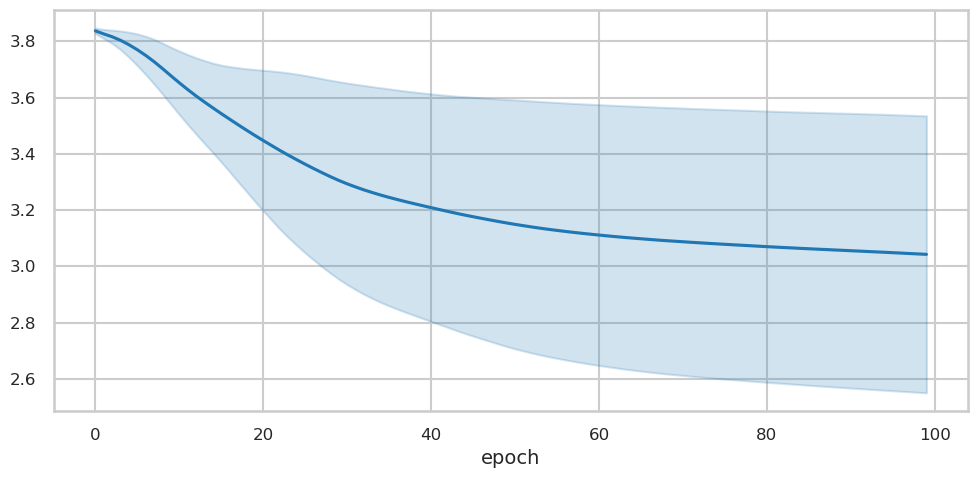

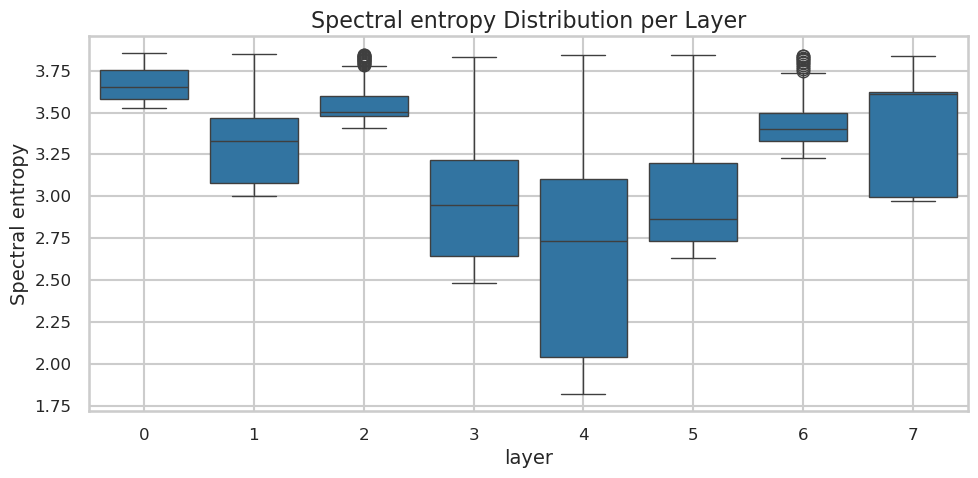

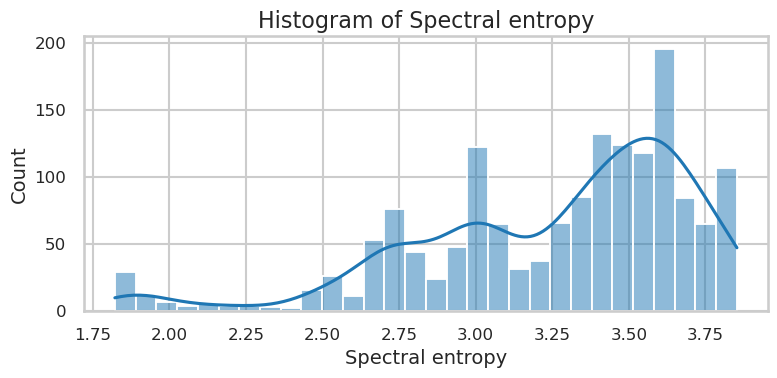

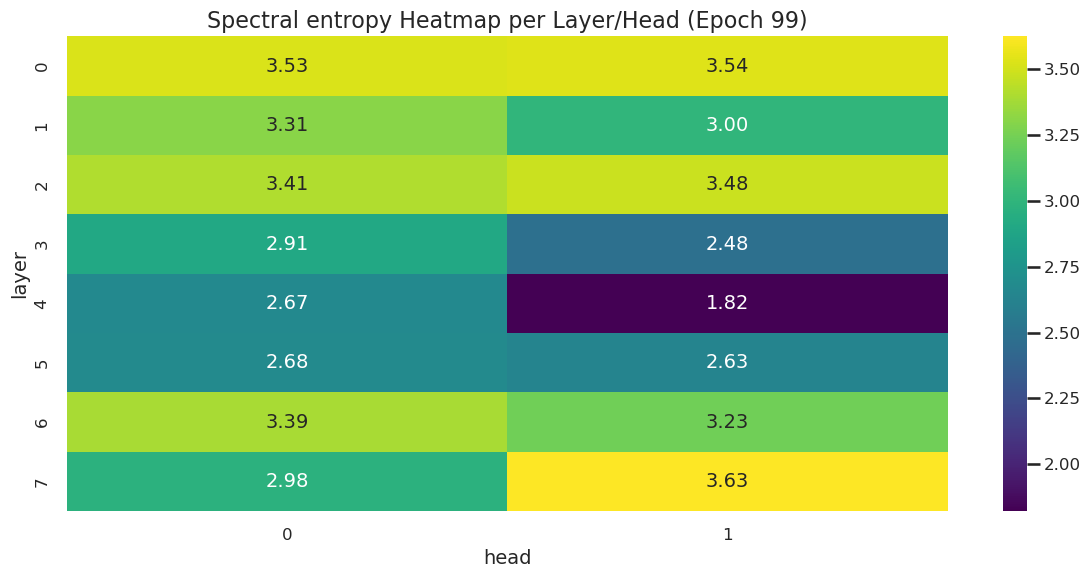

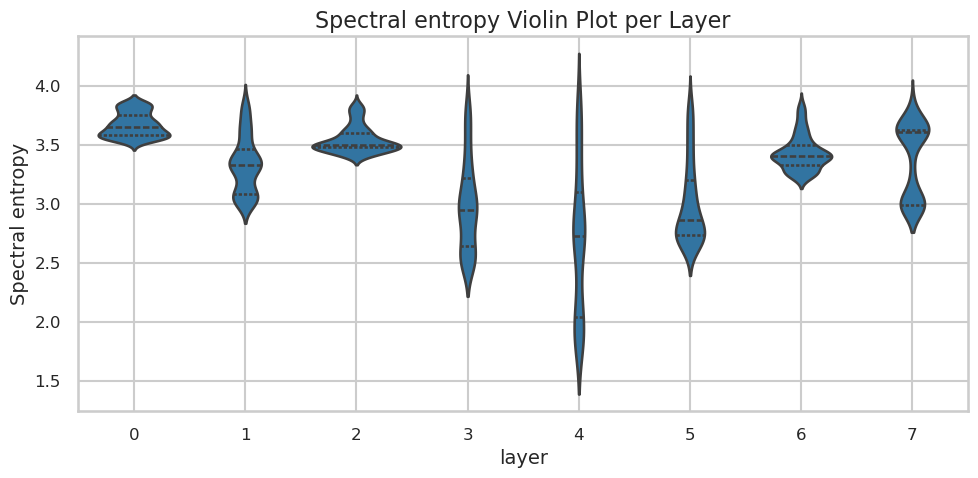

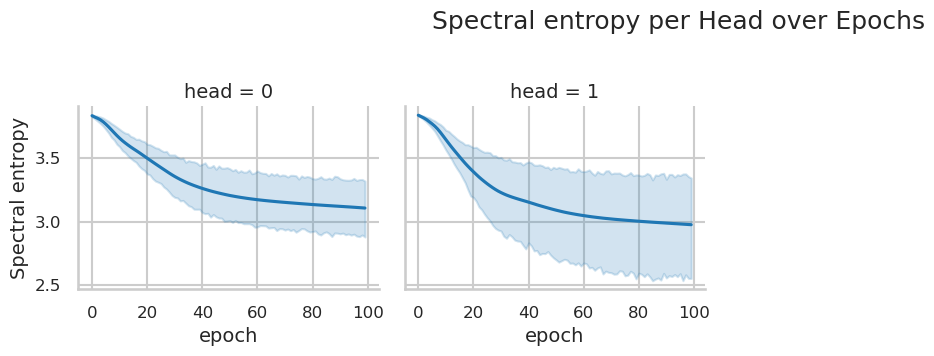


📊 Plotting Effective rank...


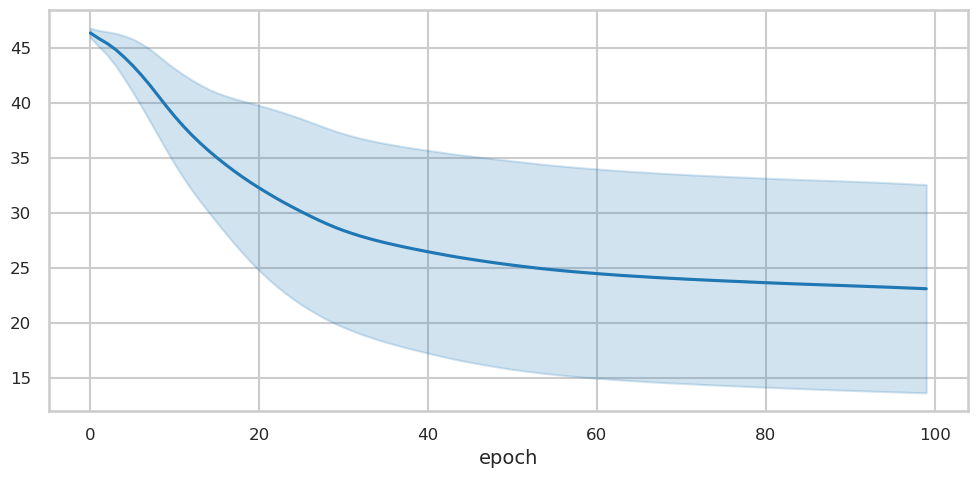

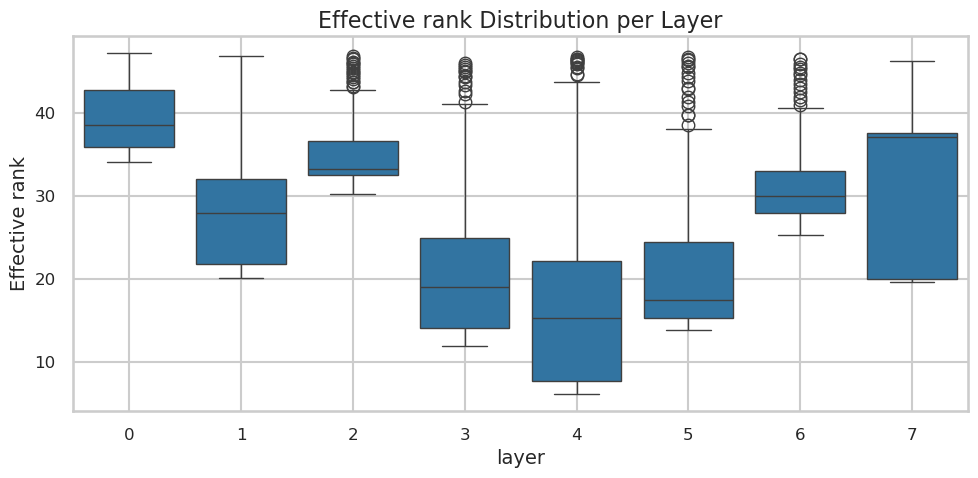

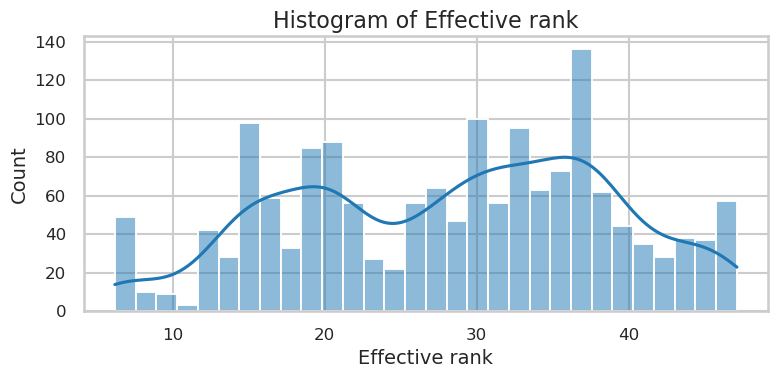

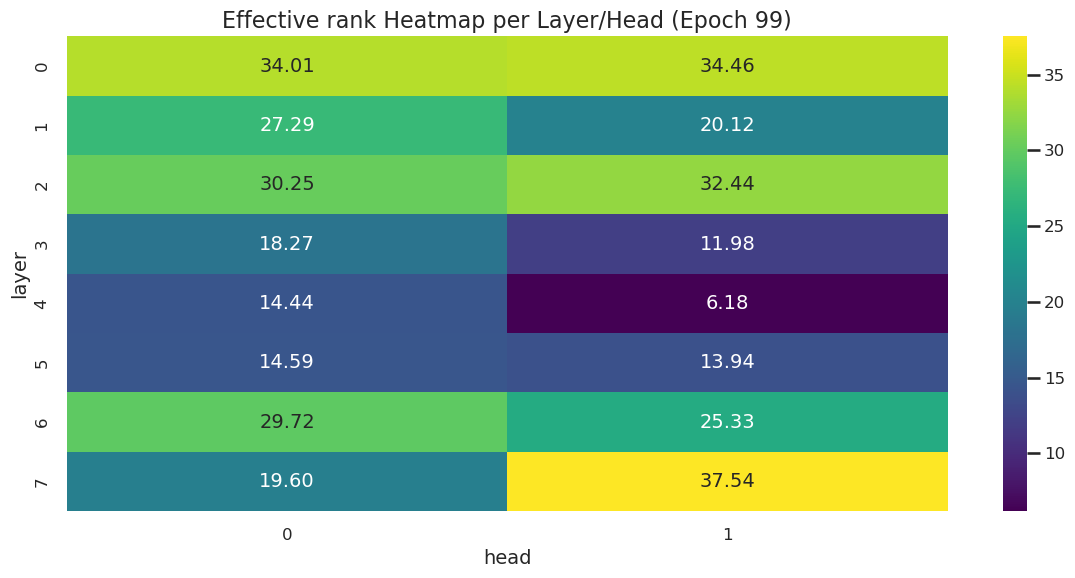

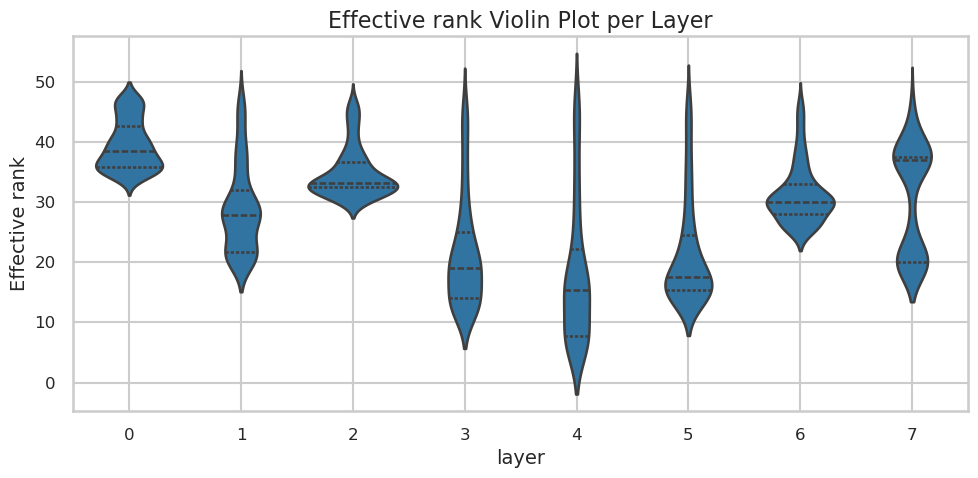

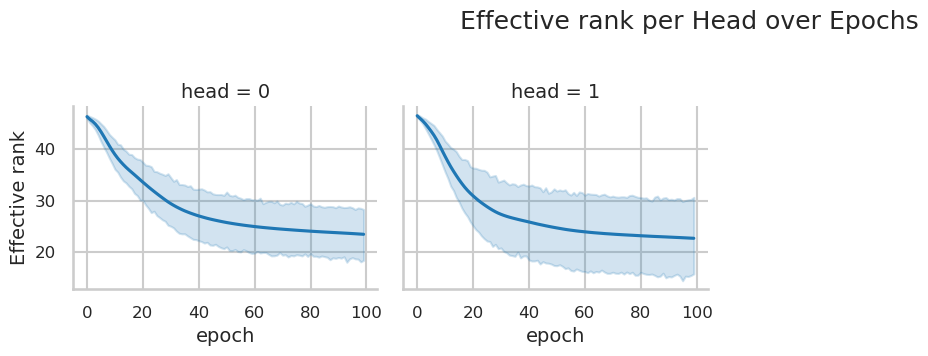


📊 Plotting Angular alignment...


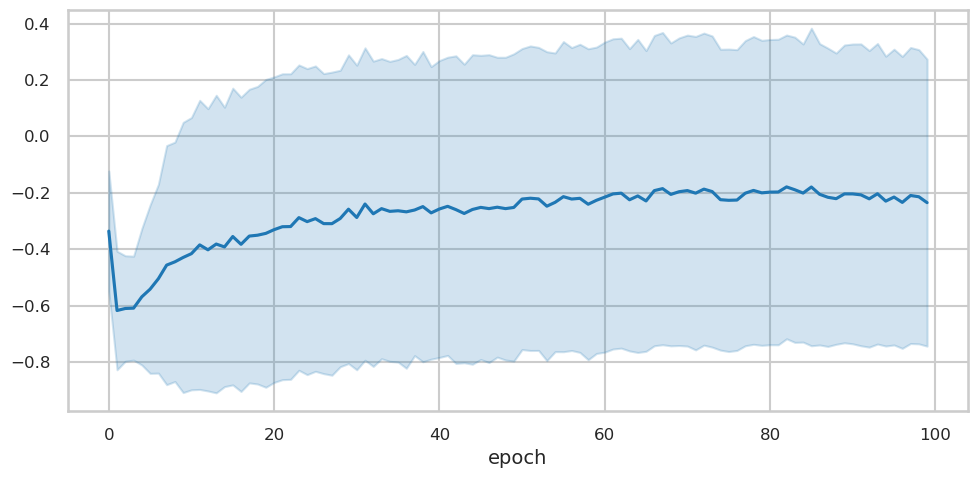

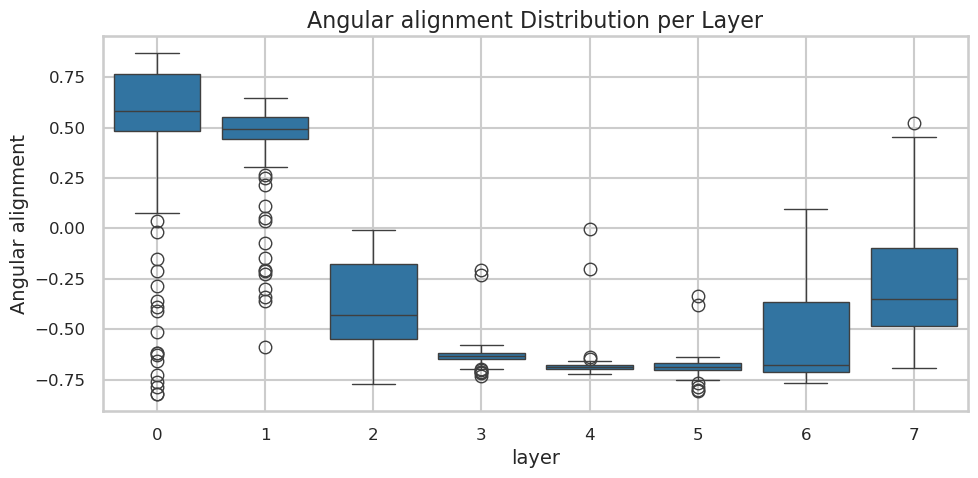

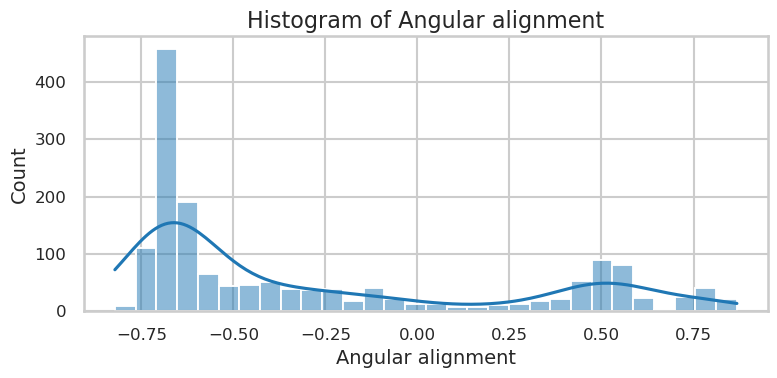

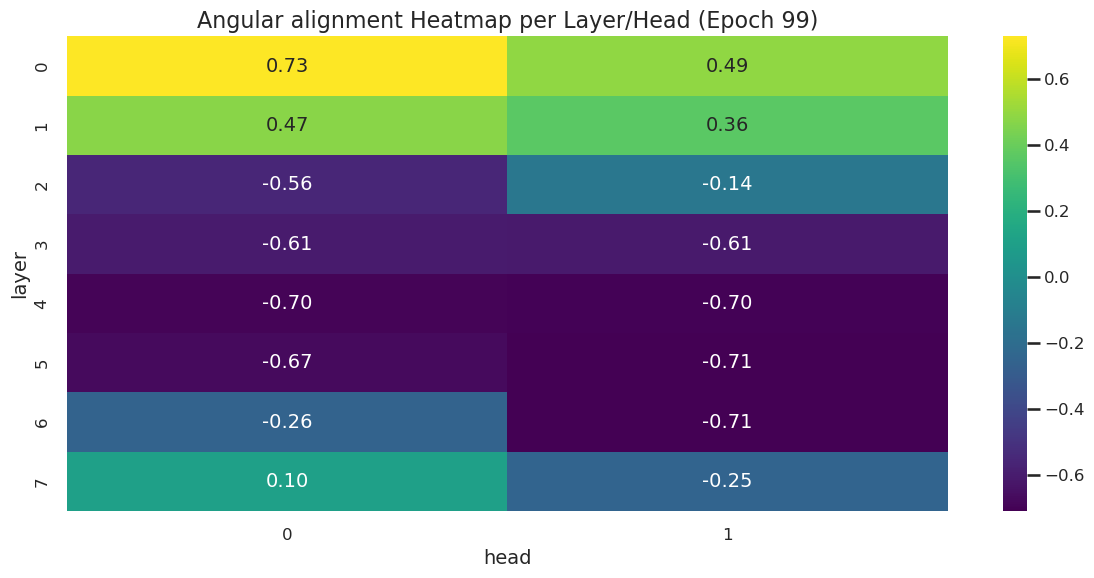

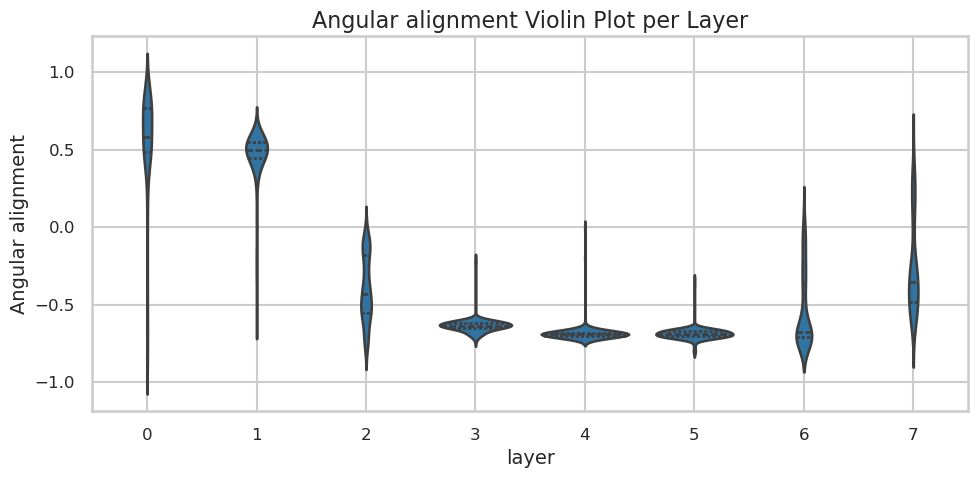

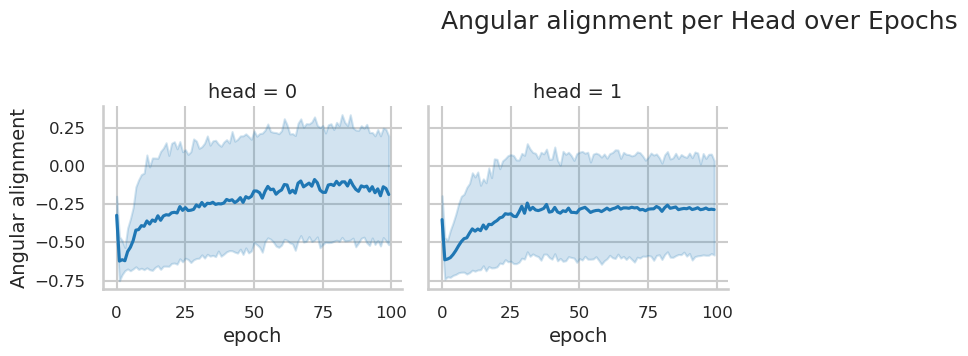


📊 Plotting Selectivity index...


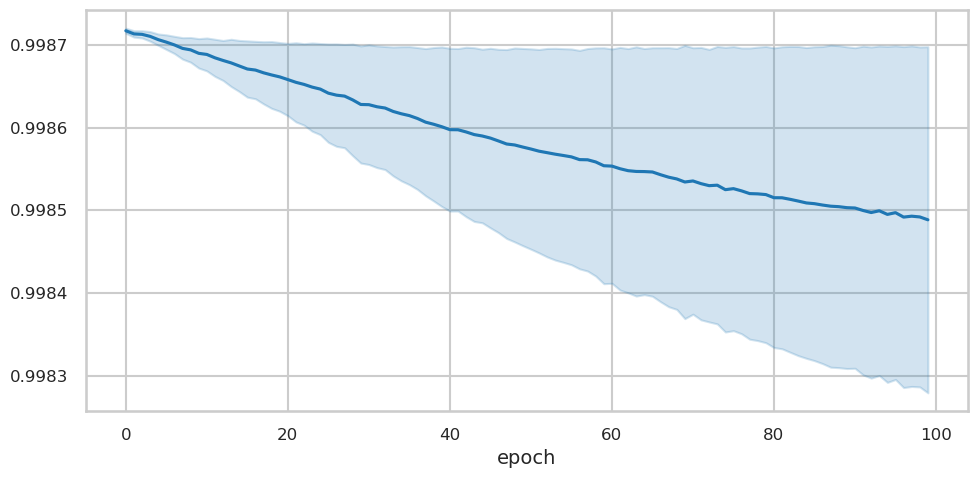

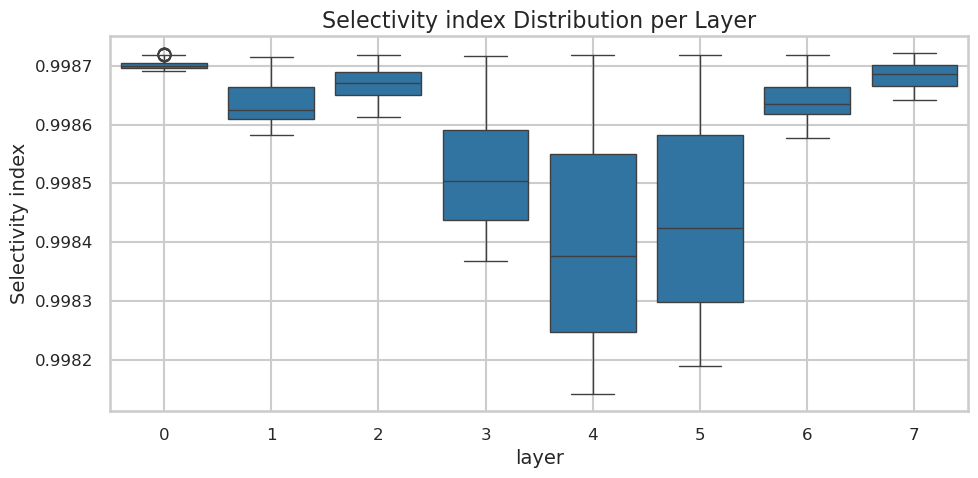

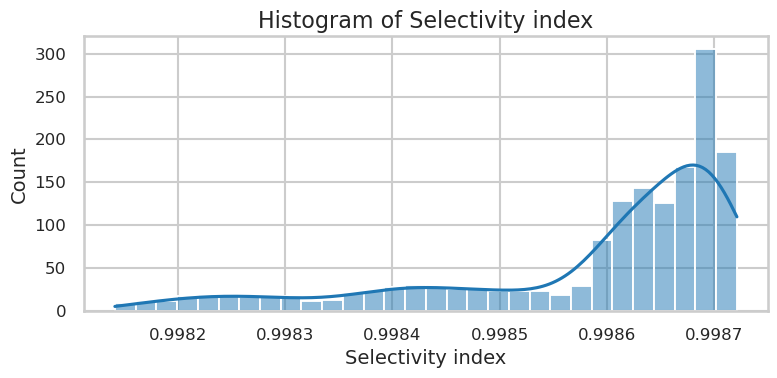

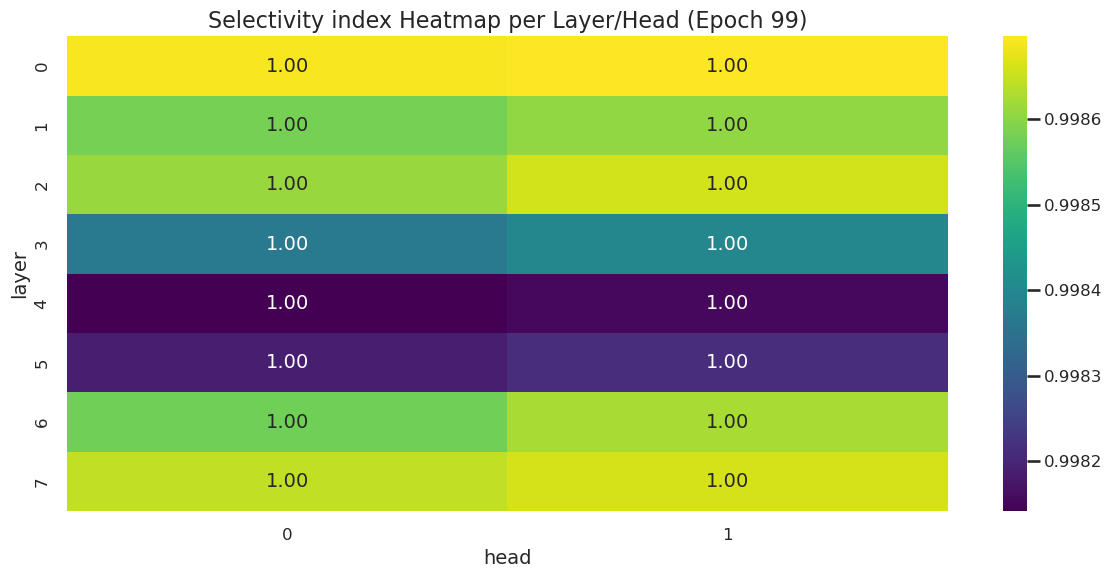

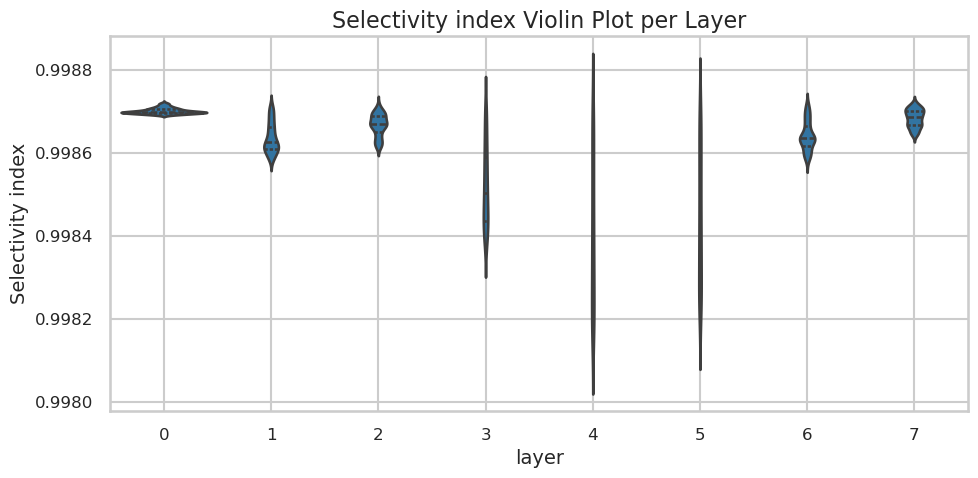

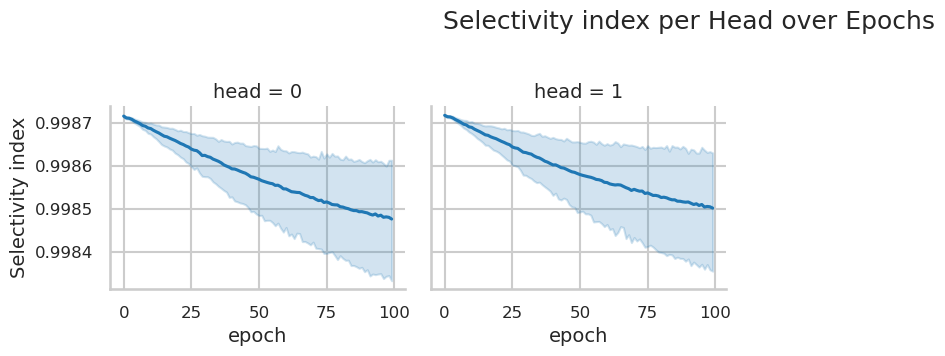


📊 Plotting Spectral sparsity...


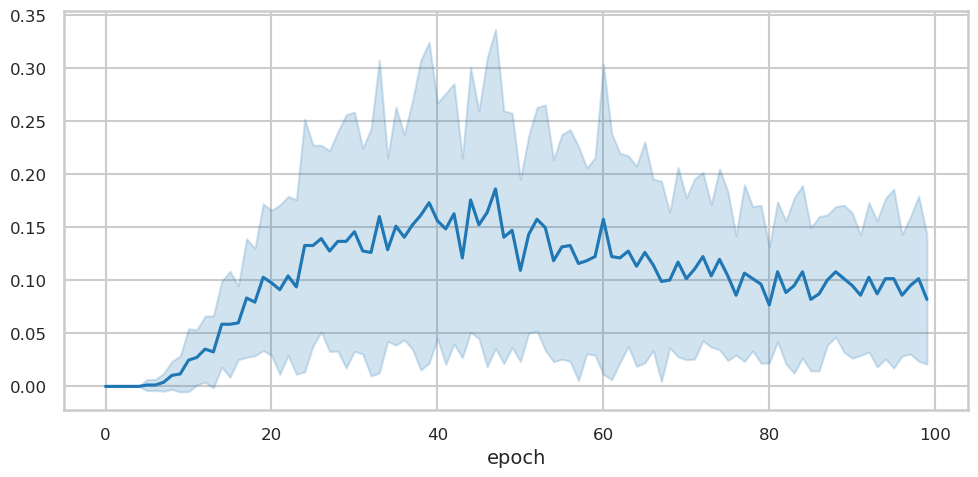

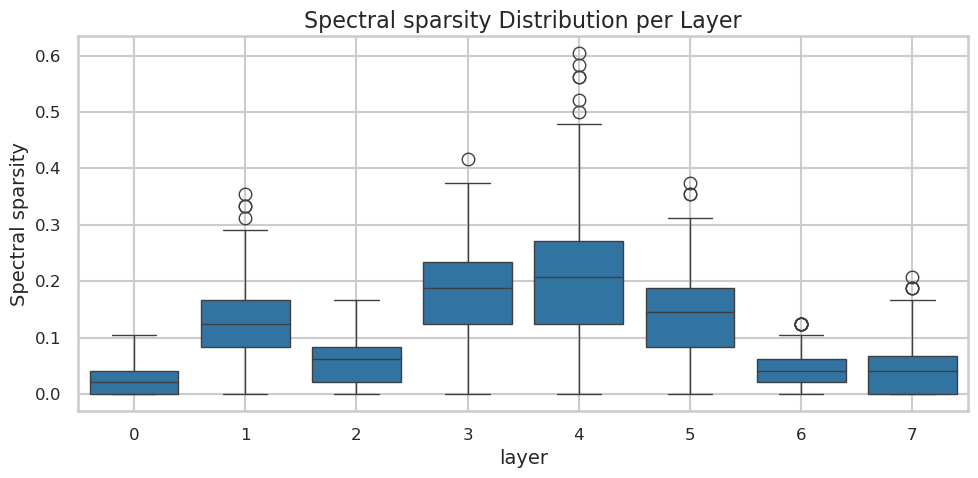

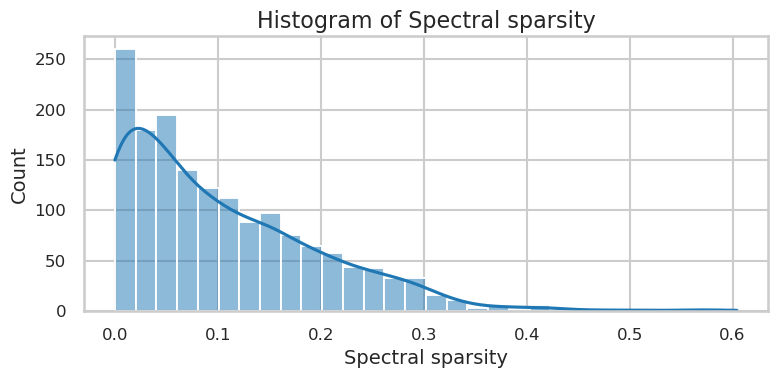

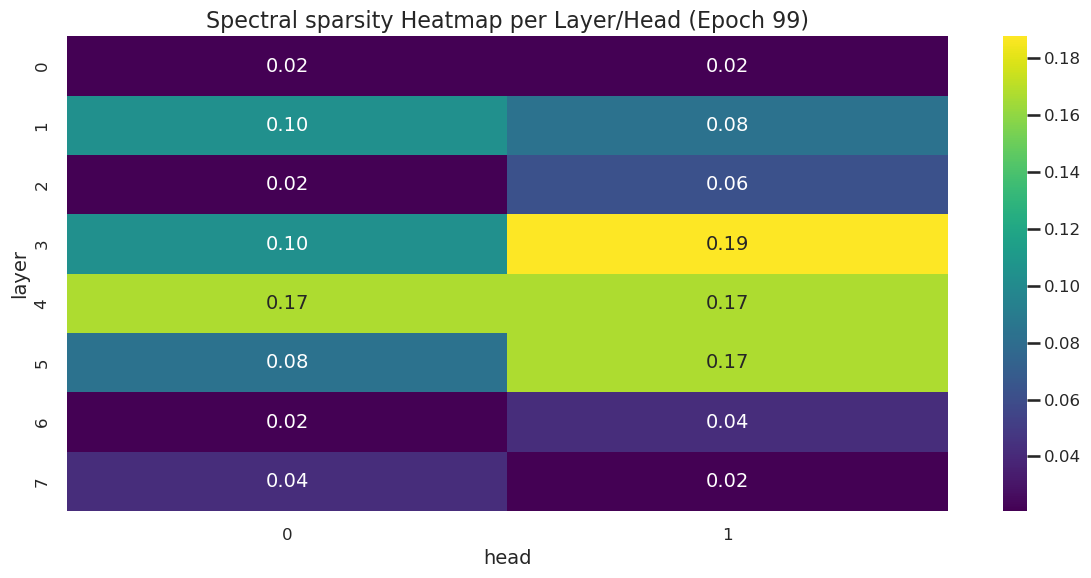

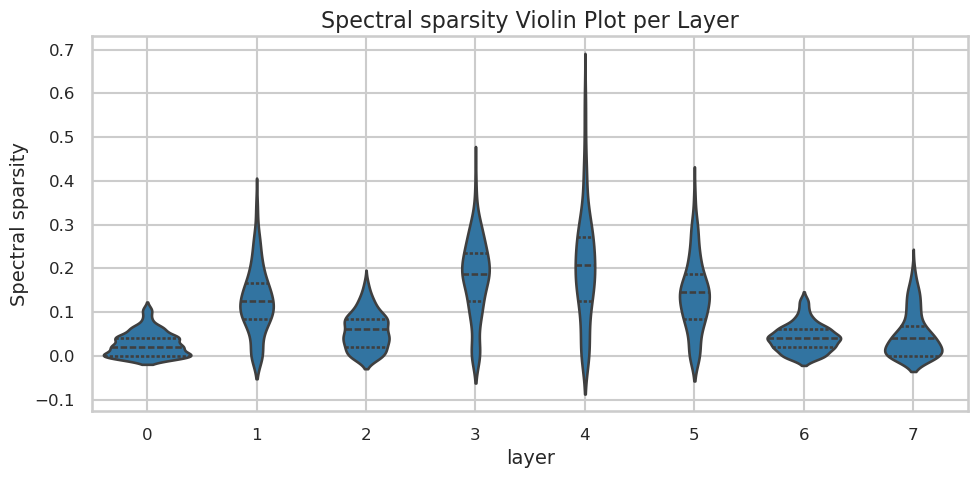

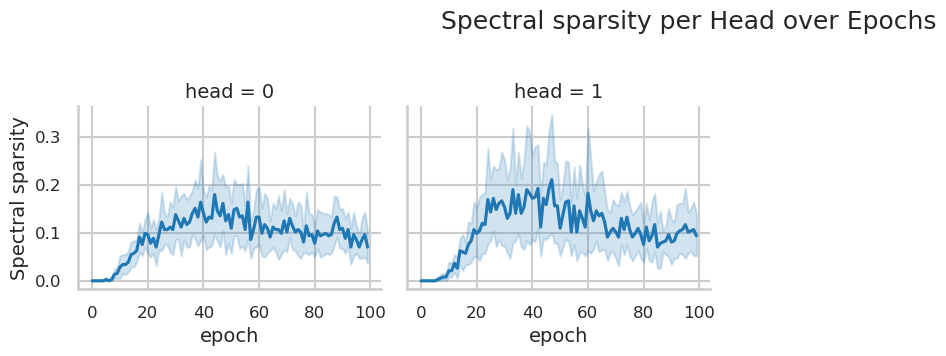


📊 Plotting Perturbation robustness...


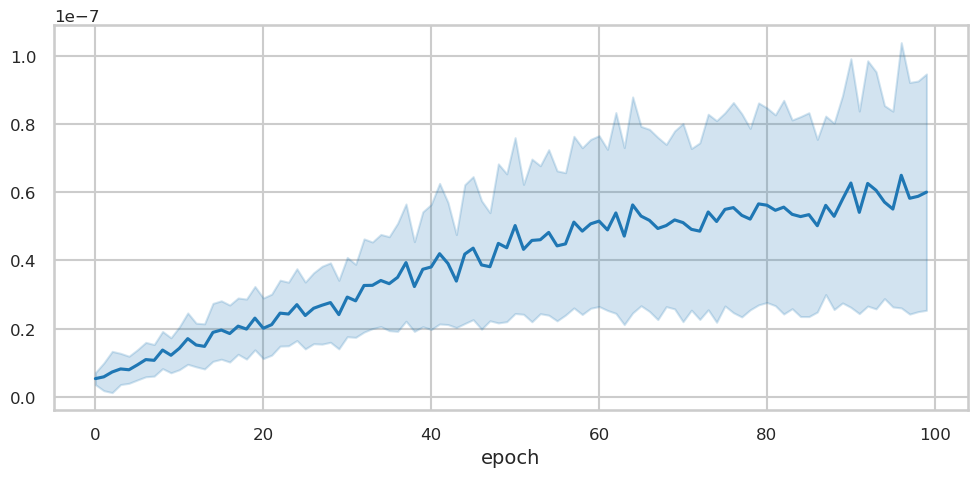

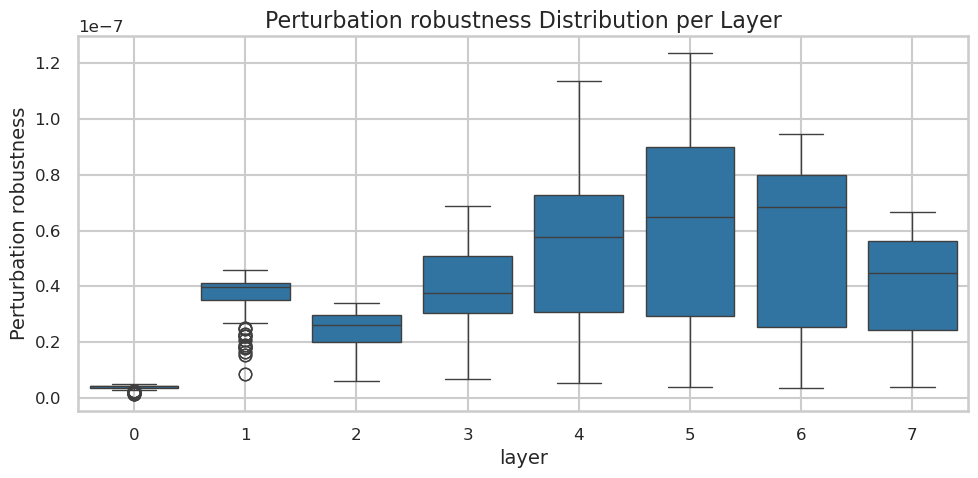

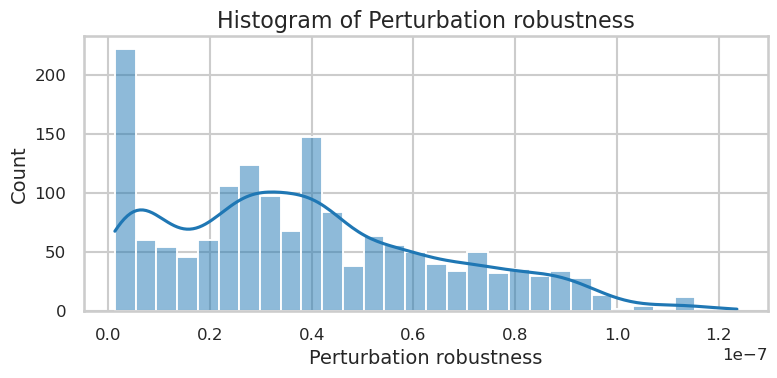

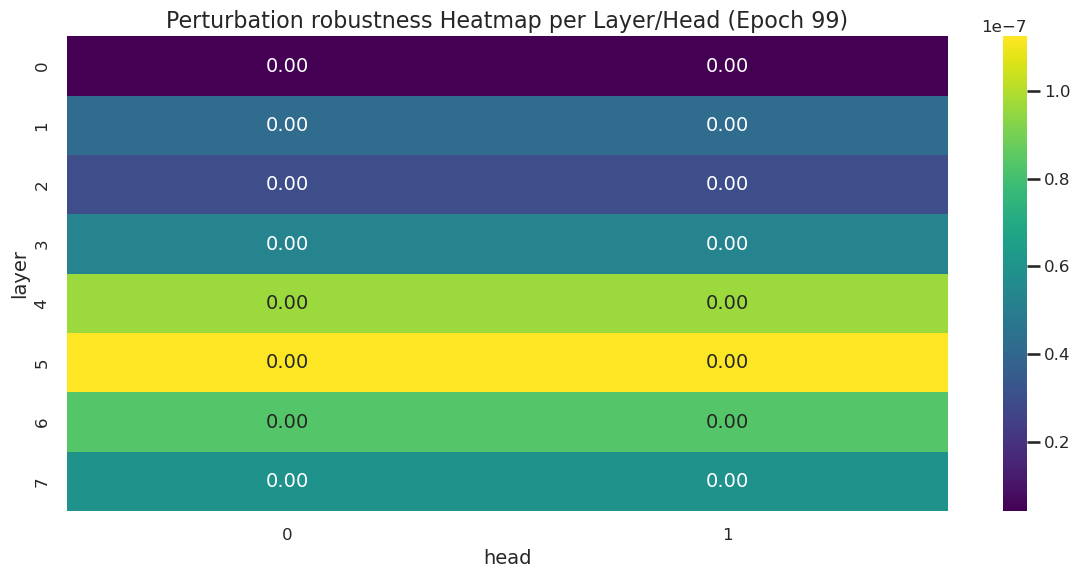

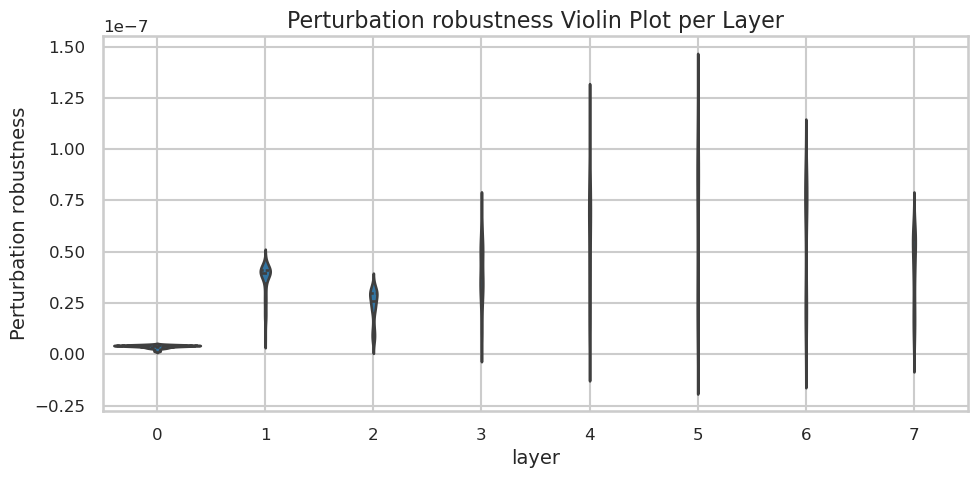

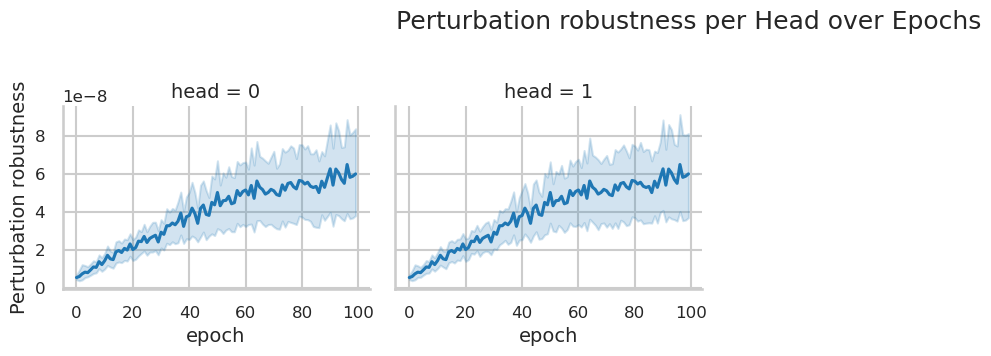

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load metrics from .npy files
import glob
import os

# Replace this path with your actual logs directory
log_dir = "logs_svda_imagenet100"
seed = 42  # Replace or iterate over seeds if needed
sample_array = np.load(os.path.join(log_dir, f"entropy_layerwise_seed{seed}.npy"))  # shape: (E, L, H)
num_epochs, num_layers, num_heads = sample_array.shape

# Set global font scale and styles
sns.set_context("talk")  # alternatives: paper, notebook, talk, poster
sns.set_style("whitegrid")  # clean grid style
plt.rcParams.update({
    "font.size": 14,            # base font size
    "axes.titlesize": 16,       # title font
    "axes.labelsize": 14,       # axis label font
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 18
})

def load_metric_array(name):
    return np.load(os.path.join(log_dir, f"{name}_layerwise_seed{seed}.npy"))  # shape: (E, L, H)

df_records = []
for epoch in range(num_epochs):
    for layer in range(num_layers):
        for head in range(num_heads):
            record = {
                "epoch": epoch,
                "layer": layer,
                "head": head,
                "Spectral entropy": load_metric_array("entropy")[epoch, layer, head],
                "Effective rank": load_metric_array("rank")[epoch, layer, head],
                "Angular alignment": load_metric_array("angular_alignment")[epoch, layer, head],
                "Selectivity index": load_metric_array("selectivity")[epoch, layer, head],
                "Spectral sparsity": load_metric_array("sparsity")[epoch, layer, head],
                "Perturbation robustness": load_metric_array("robustness")[epoch, layer],  # shape: (E, L)
            }
            df_records.append(record)

df = pd.DataFrame(df_records)

# Ensure proper column types
df['epoch'] = df['epoch'].astype(int)
df['layer'] = df['layer'].astype(int)
df['head'] = df['head'].astype(int)

# List of metrics to analyze
metrics = [
    'Spectral entropy', 'Effective rank',
    'Angular alignment', 'Selectivity index',
    'Spectral sparsity', 'Perturbation robustness'
]

# Plotting functions
def plot_metric_by_epoch(df, metric):
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x="epoch", y=metric, estimator="mean", errorbar="sd")
    # plt.title(f"{metric} over Epochs")
    plt.ylabel("")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_metric_by_layer(df, metric):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="layer", y=metric)
    plt.title(f"{metric} Distribution per Layer")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_metric_histogram(df, metric):
    plt.figure(figsize=(8, 4))
    sns.histplot(df[metric], bins=30, kde=True)
    plt.title(f"Histogram of {metric}")
    plt.tight_layout()
    plt.show()

def plot_head_layer_heatmap(df, metric, epoch=None):
    subset = df[df["epoch"] == epoch] if epoch is not None else df
    pivot = subset.pivot_table(index="layer", columns="head", values=metric)
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".2f")
    plt.title(f"{metric} Heatmap per Layer/Head" + (f" (Epoch {epoch})" if epoch is not None else ""))
    plt.tight_layout()
    plt.show()

def plot_metric_violin_by_layer(df, metric):
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x="layer", y=metric, inner="quartile")
    plt.title(f"{metric} Violin Plot per Layer")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def facet_metric_by_head(df, metric):
    g = sns.FacetGrid(df, col="head", col_wrap=4, height=3.5)
    g.map(sns.lineplot, "epoch", metric)
    g.fig.suptitle(f"{metric} per Head over Epochs", y=1.02)
    plt.tight_layout()
    plt.show()

# Iterate over all metrics
for metric in metrics:
    print(f"\n📊 Plotting {metric}...")
    plot_metric_by_epoch(df, metric)
    plot_metric_by_layer(df, metric)
    plot_metric_histogram(df, metric)
    plot_head_layer_heatmap(df, metric, epoch=df['epoch'].max())  # Latest epoch
    plot_metric_violin_by_layer(df, metric)
    facet_metric_by_head(df, metric)

# Save summary statistics
summary = df.groupby("epoch")[metrics].agg(['mean', 'std'])
summary.to_csv("metric_summary_over_epochs.csv")